<a href="https://colab.research.google.com/github/31251026017/homeworkAI-23.1-23.15/blob/main/2_11_2_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 22.3 MB/s eta 0:00:00


Giá đi xe (0-100): 91.73
Điểm thưởng (0-100): 86.39


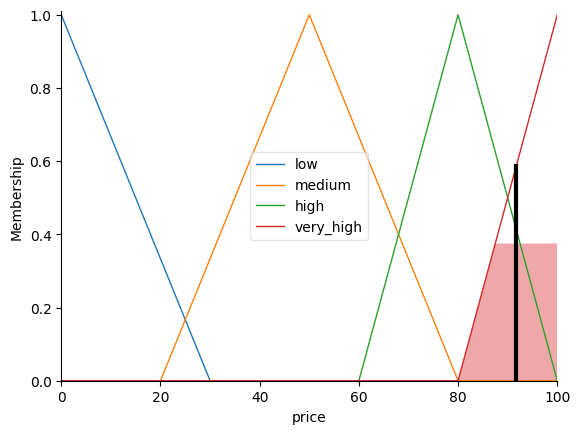

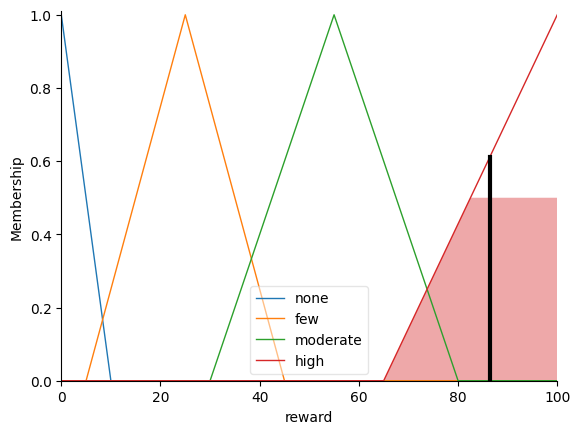

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 101, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')
distance['short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['very_long'] = fuzz.trimf(distance.universe, [15, 50, 50])

traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 45, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 45, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

weather['good'] = fuzz.trimf(weather.universe, [0, 0, 40])
weather['moderate'] = fuzz.trimf(weather.universe, [30, 50, 70])
weather['bad'] = fuzz.trimf(weather.universe, [60, 100, 100])

rating['poor'] = fuzz.trimf(rating.universe, [1.0, 1.0, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2.0, 3.0, 4.0])
rating['good'] = fuzz.trimf(rating.universe, [3.5, 5.0, 5.0])

punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['on_time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trimf(punctuality.universe, [70, 100, 100])

price['low'] = fuzz.trimf(price.universe, [0, 0, 30])
price['medium'] = fuzz.trimf(price.universe, [20, 50, 80])
price['high'] = fuzz.trimf(price.universe, [60, 80, 100])
price['very_high'] = fuzz.trimf(price.universe, [80, 100, 100])

reward['none'] = fuzz.trimf(reward.universe, [0, 0, 10])
reward['few'] = fuzz.trimf(reward.universe, [5, 25, 45])
reward['moderate'] = fuzz.trimf(reward.universe, [30, 55, 80])
reward['high'] = fuzz.trimf(reward.universe, [65, 100, 100])
rule1 = ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2 = ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3 = ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4 = ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5 = ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high'])
rule6 = ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high'])
rule7 = ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8 = ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high'])
rule9 = ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high'])
rule10 = ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium'])

rule11 = ctrl.Rule(rating['good'] & punctuality['early'], reward['high'])
rule12 = ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate'])
rule13 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule14 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high'])
rule15 = ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate'])
rule16 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule17 = ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high'])
rule18 = ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few'])
rule19 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few'])
rule20 = ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])

grab_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
                                rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])

grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['distance'] = 12
grab_sim.input['traffic'] = 80
grab_sim.input['demand'] = 90
grab_sim.input['weather'] = 75
grab_sim.input['rating'] = 4.2
grab_sim.input['punctuality'] = 50
grab_sim.compute()

print(f"Giá đi xe (0-100): {grab_sim.output['price']:.2f}")
print(f"Điểm thưởng (0-100): {grab_sim.output['reward']:.2f}")

price.view(sim=grab_sim)
reward.view(sim=grab_sim)

Mức giảm giá đề xuất (%): 55.916666666666664


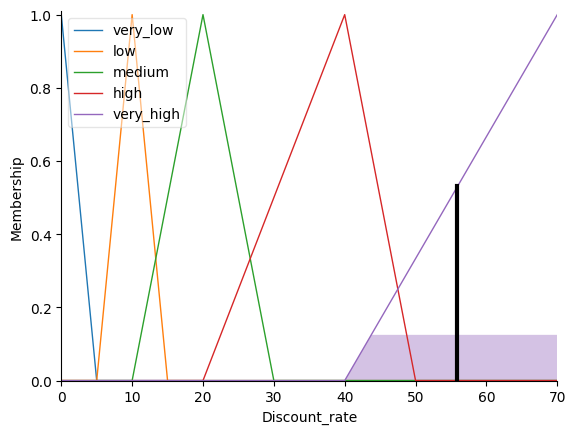

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store_rating')
Sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'Sales_volume')
Profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'Profit_margin')
Seasonal_event = ctrl.Antecedent(np.arange(0, 101, 1), 'Seasonal_event')
Competitor_Discounts = ctrl.Antecedent(np.arange(0, 101, 1), 'Competitor_Discounts')

Discount_rate = ctrl.Consequent(np.arange(0, 71, 1), 'Discount_rate')

Store_rating['low'] = fuzz.trimf(Store_rating.universe, [0, 0, 4])
Store_rating['medium'] = fuzz.trimf(Store_rating.universe, [4, 4.25, 4.5])
Store_rating['high'] = fuzz.trimf(Store_rating.universe, [4.5, 5, 5])

Sales_volume['low'] = fuzz.trimf(Sales_volume.universe, [0, 0, 40])
Sales_volume['medium'] = fuzz.trimf(Sales_volume.universe, [30, 50, 70])
Sales_volume['high'] = fuzz.trimf(Sales_volume.universe, [60, 100, 100])

Profit_margin['low'] = fuzz.trimf(Profit_margin.universe, [0, 0, 30])
Profit_margin['medium'] = fuzz.trimf(Profit_margin.universe, [20, 50, 70])
Profit_margin['high'] = fuzz.trimf(Profit_margin.universe, [60, 100, 100])

Seasonal_event['none'] = fuzz.trimf(Seasonal_event.universe, [0, 0, 20])
Seasonal_event['medium'] = fuzz.trimf(Seasonal_event.universe, [20, 50, 70])
Seasonal_event['high'] = fuzz.trimf(Seasonal_event.universe, [60, 100, 100])

Competitor_Discounts['low'] = fuzz.trimf(Competitor_Discounts.universe, [0, 0, 30])
Competitor_Discounts['medium'] = fuzz.trimf(Competitor_Discounts.universe, [20, 50, 70])
Competitor_Discounts['high'] = fuzz.trimf(Competitor_Discounts.universe, [60, 100, 100])

Discount_rate['very_low'] = fuzz.trimf(Discount_rate.universe, [0, 0, 5])
Discount_rate['low'] = fuzz.trimf(Discount_rate.universe, [5, 10, 15])
Discount_rate['medium'] = fuzz.trimf(Discount_rate.universe, [10, 20, 30])
Discount_rate['high'] = fuzz.trimf(Discount_rate.universe, [20, 40, 50])
Discount_rate['very_high'] = fuzz.trimf(Discount_rate.universe, [40, 70, 70])

rules = [
    ctrl.Rule(Store_rating['high'] & Sales_volume['high'] & Profit_margin['high'], Discount_rate['very_low']),
    ctrl.Rule(Store_rating['low'] & Sales_volume['low'] & Profit_margin['high'], Discount_rate['high']),
    ctrl.Rule(Seasonal_event['high'] & Competitor_Discounts['high'], Discount_rate['very_high']),
    ctrl.Rule(Store_rating['medium'] & Sales_volume['medium'] & Profit_margin['medium'], Discount_rate['medium']),
    ctrl.Rule(Competitor_Discounts['low'] & Profit_margin['low'] & Sales_volume['high'], Discount_rate['very_low']),
    ctrl.Rule(Store_rating['low'] & Seasonal_event['none'], Discount_rate['medium']),
    ctrl.Rule(Sales_volume['low'] & Profit_margin['low'], Discount_rate['very_high']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Store_rating'] = 4
sim.input['Sales_volume'] = 50
sim.input['Profit_margin'] = 25
sim.input['Seasonal_event'] = 90
sim.input['Competitor_Discounts'] = 65

sim.compute()

print("Mức giảm giá đề xuất (%):", sim.output['Discount_rate'])

Discount_rate.view(sim=sim)

Mức giảm giá đề xuất (%): 25.000000000000004


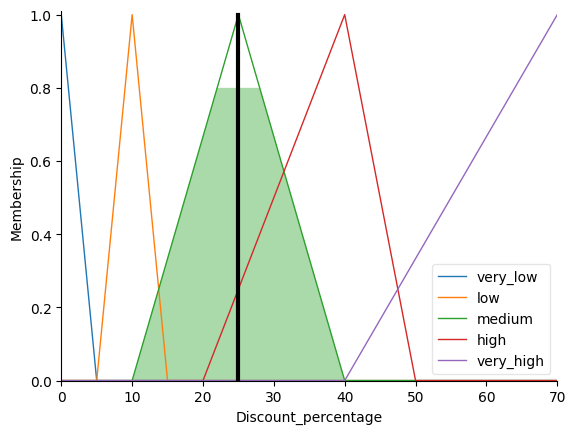

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Product_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'Product_demand')
Competitor_pricing_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'Competitor_pricing_pressure')
Store_reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store_reputation')
Profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'Profit_margin')
Seasonal_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'Seasonal_demand')

Discount_percentage = ctrl.Consequent(np.arange(0, 71, 1), 'Discount_percentage')

Product_demand['low'] = fuzz.trimf(Product_demand.universe, [0, 0, 40])
Product_demand['medium'] = fuzz.trimf(Product_demand.universe, [30, 50, 70])
Product_demand['high'] = fuzz.trimf(Product_demand.universe, [60, 100, 100])

Competitor_pricing_pressure['low'] = fuzz.trimf(Competitor_pricing_pressure.universe, [0, 0, 30])
Competitor_pricing_pressure['medium'] = fuzz.trimf(Competitor_pricing_pressure.universe, [30, 50, 70])
Competitor_pricing_pressure['high'] = fuzz.trimf(Competitor_pricing_pressure.universe, [60, 100, 100])

Store_reputation['low'] = fuzz.trimf(Store_reputation.universe, [0, 0, 4])
Store_reputation['medium'] = fuzz.trimf(Store_reputation.universe, [4, 4.25, 4.5])
Store_reputation['high'] = fuzz.trimf(Store_reputation.universe, [4.5, 5, 5])

Profit_margin['low'] = fuzz.trimf(Profit_margin.universe, [0, 0, 30])
Profit_margin['medium'] = fuzz.trimf(Profit_margin.universe, [20, 50, 70])
Profit_margin['high'] = fuzz.trimf(Profit_margin.universe, [60, 100, 100])

Seasonal_demand['none'] = fuzz.trimf(Seasonal_demand.universe, [0, 0, 20])
Seasonal_demand['medium'] = fuzz.trimf(Seasonal_demand.universe, [20, 50, 70])
Seasonal_demand['high'] = fuzz.trimf(Seasonal_demand.universe, [60, 100, 100])

Discount_percentage['very_low'] = fuzz.trimf(Discount_percentage.universe, [0, 0, 5])
Discount_percentage['low'] = fuzz.trimf(Discount_percentage.universe, [5, 10, 15])
Discount_percentage['medium'] = fuzz.trimf(Discount_percentage.universe, [10, 25, 40])
Discount_percentage['high'] = fuzz.trimf(Discount_percentage.universe, [20, 40, 50])
Discount_percentage['very_high'] = fuzz.trimf(Discount_percentage.universe, [40, 70, 70])

rules = [
    ctrl.Rule(Product_demand['high'] & Competitor_pricing_pressure['low'] & Profit_margin['low'], Discount_percentage['very_low']),
    ctrl.Rule(Product_demand['low'] & Competitor_pricing_pressure['high'] & Profit_margin['high'], Discount_percentage['high']),
    ctrl.Rule(Store_reputation['medium'] & Seasonal_demand['medium'], Discount_percentage['medium']),
    ctrl.Rule(Competitor_pricing_pressure['high'] & Seasonal_demand['high'] & Profit_margin['high'], Discount_percentage['very_high']),
    ctrl.Rule(Store_reputation['low'] & Product_demand['medium'] & Profit_margin['low'], Discount_percentage['medium']),
    ctrl.Rule(Product_demand['high'] & Seasonal_demand['none'] & Competitor_pricing_pressure['low'], Discount_percentage['very_low']),
    ctrl.Rule(Profit_margin['high'] & Competitor_pricing_pressure['medium'] & Seasonal_demand['medium'], Discount_percentage['medium']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Product_demand'] = 50
sim.input['Competitor_pricing_pressure'] = 50
sim.input['Store_reputation'] = 4.25
sim.input['Profit_margin'] = 50
sim.input['Seasonal_demand'] = 50

sim.compute()

print("Mức giảm giá đề xuất (%):", sim.output['Discount_percentage'])

Discount_percentage.view(sim=sim)

KẾT QUẢ SUY DIỄN:
Giá đi xe (0-100): 90.28
Điểm thưởng (0-100): 83.00


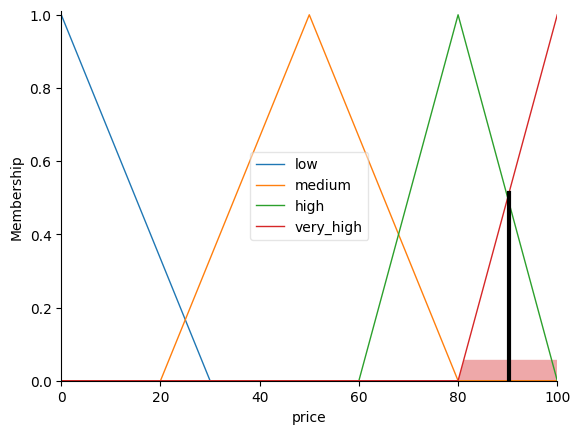

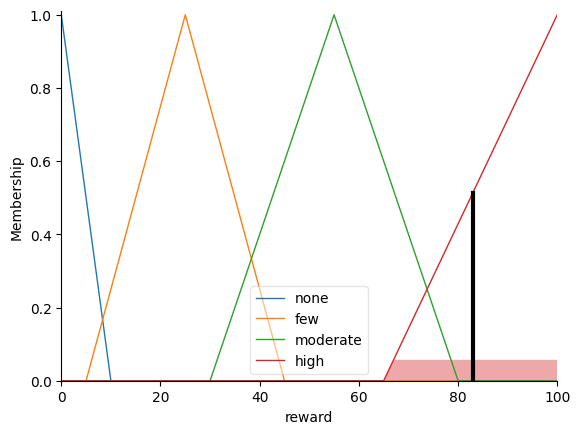

In [ ]:
rule1 = ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2 = ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3 = ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4 = ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5 = ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high'])
rule6 = ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high'])
rule7 = ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8 = ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high'])
rule9 = ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high'])
rule10 = ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium'])

rule11 = ctrl.Rule(rating['good'] & punctuality['early'], reward['high'])
rule12 = ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate'])
rule13 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule14 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high'])
rule15 = ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate'])
rule16 = ctrl.Rule(rating['poor'] & punctuality['late'], reward['none'])
rule17 = ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high'])
rule18 = ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few'])
rule19 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few'])
rule20 = ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])

grab_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
                                rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])

grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['distance'] = 17
grab_sim.input['traffic'] = 60
grab_sim.input['demand'] = 70
grab_sim.input['weather'] = 85
grab_sim.input['rating'] = 4.5
grab_sim.input['punctuality'] = 50

grab_sim.compute()

print("KẾT QUẢ SUY DIỄN:")
print(f"Giá đi xe (0-100): {grab_sim.output['price']:.2f}")
print(f"Điểm thưởng (0-100): {grab_sim.output['reward']:.2f}")

price.view(sim=grab_sim)
reward.view(sim=grab_sim)

Mức ưu tiên giao: 63.117061021170606


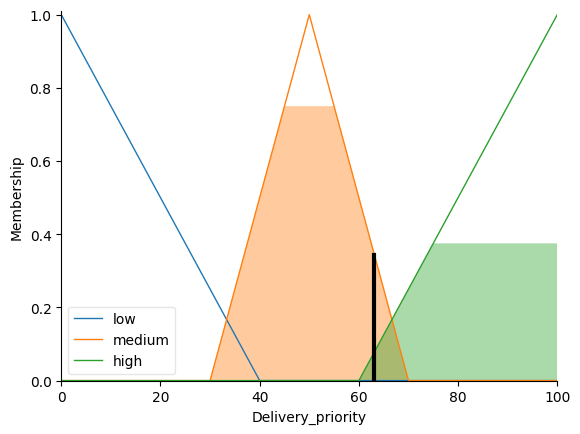

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'Order_density')
Delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'Delivery_urgency')
Driver_current_load = ctrl.Antecedent(np.arange(0, 101, 1), 'Driver_current_load')
Traffic_condition = ctrl.Antecedent(np.arange(0, 101, 1), 'Traffic_condition')
Profit_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'Profit_delivery')

Orders_to_combine = ctrl.Consequent(np.arange(0, 11, 1), 'Orders_to_combine')
Delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'Delivery_priority')

Order_density['low'] = fuzz.trimf(Order_density.universe, [0, 0, 40])
Order_density['medium'] = fuzz.trimf(Order_density.universe, [30, 50, 70])
Order_density['high'] = fuzz.trimf(Order_density.universe, [60, 100, 100])

Delivery_urgency['low'] = fuzz.trimf(Delivery_urgency.universe, [0, 0, 40])
Delivery_urgency['medium'] = fuzz.trimf(Delivery_urgency.universe, [30, 50, 70])
Delivery_urgency['high'] = fuzz.trimf(Delivery_urgency.universe, [60, 100, 100])

Driver_current_load['low'] = fuzz.trimf(Driver_current_load.universe, [0, 0, 40])
Driver_current_load['medium'] = fuzz.trimf(Driver_current_load.universe, [30, 50, 70])
Driver_current_load['high'] = fuzz.trimf(Driver_current_load.universe, [60, 100, 100])

Traffic_condition['low'] = fuzz.trimf(Traffic_condition.universe, [0, 0, 40])
Traffic_condition['medium'] = fuzz.trimf(Traffic_condition.universe, [30, 50, 70])
Traffic_condition['high'] = fuzz.trimf(Traffic_condition.universe, [60, 100, 100])

Profit_delivery['low'] = fuzz.trimf(Profit_delivery.universe, [0, 0, 40])
Profit_delivery['medium'] = fuzz.trimf(Profit_delivery.universe, [30, 50, 70])
Profit_delivery['high'] = fuzz.trimf(Profit_delivery.universe, [60, 100, 100])

Orders_to_combine['few'] = fuzz.trimf(Orders_to_combine.universe, [0, 1, 3])
Orders_to_combine['some'] = fuzz.trimf(Orders_to_combine.universe, [2, 5, 7])
Orders_to_combine['many'] = fuzz.trimf(Orders_to_combine.universe, [6, 10, 10])

Delivery_priority['low'] = fuzz.trimf(Delivery_priority.universe, [0, 0, 40])
Delivery_priority['medium'] = fuzz.trimf(Delivery_priority.universe, [30, 50, 70])
Delivery_priority['high'] = fuzz.trimf(Delivery_priority.universe, [60, 100, 100])

rules = [
    ctrl.Rule(Order_density['high'] & Driver_current_load['low'] & Traffic_condition['low'], Orders_to_combine['many']),
    ctrl.Rule(Order_density['medium'] & Traffic_condition['high'] & Delivery_urgency['medium'], Orders_to_combine['some']),
    ctrl.Rule(Driver_current_load['high'] & Order_density['high'] & Profit_delivery['medium'], Orders_to_combine['some']),
    ctrl.Rule(Order_density['low'] & Delivery_urgency['high'] & Traffic_condition['medium'], Orders_to_combine['some']),
    ctrl.Rule(Profit_delivery['high'] & Delivery_urgency['high'] & Traffic_condition['high'], Orders_to_combine['some']),
    ctrl.Rule(Delivery_urgency['high'] | Profit_delivery['high'], Delivery_priority['high']),
    ctrl.Rule(Delivery_urgency['medium'] | Traffic_condition['medium'], Delivery_priority['medium']),
    ctrl.Rule(Delivery_urgency['low'] & Order_density['high'], Delivery_priority['low']),
]

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

sim.input['Order_density'] = 80
sim.input['Delivery_urgency'] = 75
sim.input['Driver_current_load'] = 25
sim.input['Traffic_condition'] = 55
sim.input['Profit_delivery'] = 50

sim.compute()

if 'Delivery_priority' in sim.output:
    print("Mức ưu tiên giao:", sim.output['Delivery_priority'])
if 'Orders_to_combine' in sim.output:
    print("Số đơn hàng kết hợp:", sim.output['Orders_to_combine'])

Delivery_priority.view(sim=sim)